# Приложение Г. Добавление новых возможностей в процесс обучения

- В этом приложении мы добавляем несколько более продвинутых функций в функцию обучения, которые используются в типичном предобучении и тонкой настройке
- Следующие три раздела ниже посвящены разогреву скорости обучения, косинусному затуханию и отсечению градиентов
- В последнем разделе эти методы добавляются в функцию обучения

In [ ]:
from importlib.metadata import version
import torch

print("версия torch:", version("torch"))

from previous_chapters import GPTModel

GPT_CONFIG_124M = {
    "vocab_size": 50257,   # Размер словаря
    "context_length": 256, # Укороченная длина контекста (ориг: 1024)
    "emb_dim": 768,        # Размерность эмбеддинга
    "n_heads": 12,         # Количество голов внимания
    "n_layers": 12,        # Количество слоёв
    "drop_rate": 0.1,      # Коэффициент дропаута
    "qkv_bias": False      # Смещение для query-key-value
}

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    # Используйте PyTorch 2.9 или новее для стабильных результатов mps
    major, minor = map(int, torch.__version__.split(".")[:2])
    if (major, minor) >= (2, 9):
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
else:
    device = torch.device("cpu")

print("Устройство:", device)

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval();  # Отключаем дропаут во время инференса

версия torch: 2.12.0
Устройство: cpu


In [2]:
import os
import requests

file_path = "the-verdict.txt"
url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch02/01_main-chapter-code/the-verdict.txt"

if not os.path.exists(file_path):
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    text_data = response.text
    with open(file_path, "w", encoding="utf-8") as file:
        file.write(text_data)
else:
    with open(file_path, "r", encoding="utf-8") as file:
        text_data = file.read()

In [3]:
from previous_chapters import create_dataloader_v1

# Соотношение обучения/валидации
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))


torch.manual_seed(123)

train_loader = create_dataloader_v1(
    text_data[:split_idx],
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader = create_dataloader_v1(
    text_data[split_idx:],
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

## D.1. Переменная скорость обучения

- При обучении сложных моделей, таких как LLM, применение разогрева скорости обучения может помочь стабилизировать обучение
- При разогреве скорости обучения мы постепенно увеличиваем скорость обучения от очень низкого значения (`initial_lr`) до заданного пользователем максимума (`peak_lr`)
- Таким образом, модель начнёт обучение с малых обновлений весов, что помогает снизить риск больших дестабилизирующих обновлений в процессе обучения

In [4]:
n_epochs = 15
initial_lr = 0.0001
peak_lr = 0.01

- Обычно количество шагов разогрева составляет от 0,1% до 20% от общего числа шагов
- Мы можем вычислить приращение как разность между `peak_lr` и `initial_lr`, делённую на количество шагов разогрева

In [ ]:
total_steps = len(train_loader) * n_epochs
warmup_steps = int(0.2 * total_steps) # 20% разогрева
print(warmup_steps)

27


 ---

 ## Для чего нужны warmup_steps в обучении llm?

**Warm-up steps (шаги разогрева)** — это постепенное увеличение learning rate от нуля до целевого значения в начале обучения.

**Зачем:**
В начале обучения веса случайные, градиенты большие и нестабильные. Если сразу дать полную скорость обучения, модель может "дёрнуться" слишком сильно и сломать обучение (loss улетит в бесконечность, модель развалится).

**Как работает:**
- Первые N шагов learning rate плавно растёт (например, от 0 до 0.001).
- Потом работает обычное расписание (постоянный или затухающий learning rate).

**Аналогия:**
Машина на льду. Если сразу газ в пол — пробуксовка, потеря управления. Сначала плавно разгоняемся, потом едем нормально.

 ---

In [6]:
lr_increment = (peak_lr - initial_lr) / warmup_steps

global_step = -1
track_lrs = []

optimizer = torch.optim.AdamW(model.parameters(), weight_decay=0.1)

for epoch in range(n_epochs):
    for input_batch, target_batch in train_loader:
        optimizer.zero_grad()
        global_step += 1
    
        if global_step < warmup_steps:
            lr = initial_lr + global_step * lr_increment
        else:
            lr = peak_lr
        
        # Применяем вычисленную скорость обучения к оптимизатору
        for param_group in optimizer.param_groups:
            param_group["lr"] = lr
        track_lrs.append(optimizer.param_groups[0]["lr"])
    
        # Вычисляем потери и обновляем веса
        # ...

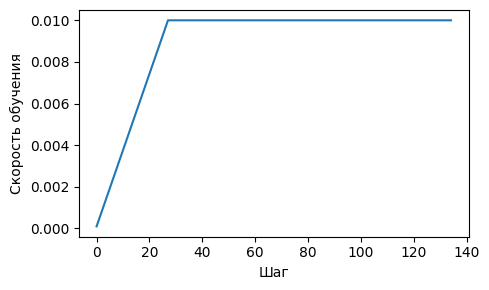

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 3))
plt.ylabel("Скорость обучения")
plt.xlabel("Шаг")
total_training_steps = len(train_loader) * n_epochs
plt.plot(range(total_training_steps), track_lrs)
plt.tight_layout(); plt.savefig("1.pdf")
plt.show()

## D.2. Затухание по косинусу

- Ещё одним популярным методом обучения сложных глубоких нейронных сетей является косинусное затухание, которое также регулирует скорость обучения на протяжении эпох обучения
- При косинусном затухании скорость обучения следует косинусной кривой, уменьшаясь от своего начального значения до почти нуля по полукосинусному циклу
- Это постепенное снижение призвано замедлить темп обучения по мере того, как модель начинает улучшать свои веса; оно снижает риск проскочить мимо минимумов по мере прогресса обучения, что критически важно для стабилизации обучения на его поздних стадиях
- Косинусное затухание часто предпочитают линейному затуханию за более плавный переход в регулировке скорости обучения, но линейное затухание также используется на практике (например, [OLMo: Accelerating the Science of Language Models](https://arxiv.org/abs/2402.00838))

In [8]:
import math

min_lr = 0.1 * initial_lr
track_lrs = []

lr_increment = (peak_lr - initial_lr) / warmup_steps
global_step = -1

for epoch in range(n_epochs):
    for input_batch, target_batch in train_loader:
        optimizer.zero_grad()
        global_step += 1
    
        # Регулируем скорость обучения в зависимости от текущей фазы (разогрев или косинусное затухание)
        if global_step < warmup_steps:
            # Линейный разогрев
            lr = initial_lr + global_step * lr_increment  
        else:
            # Косинусное затухание после разогрева
            progress = ((global_step - warmup_steps) / 
                        (total_training_steps - warmup_steps))
            lr = min_lr + (peak_lr - min_lr) * 0.5 * (
                1 + math.cos(math.pi * progress))
        
        # Применяем вычисленную скорость обучения к оптимизатору
        for param_group in optimizer.param_groups:
            param_group["lr"] = lr
        track_lrs.append(optimizer.param_groups[0]["lr"])
    
        # Вычисляем потери и обновляем веса

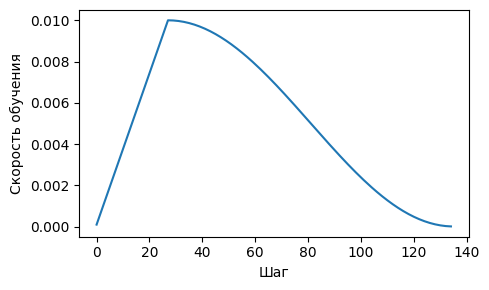

In [9]:
plt.figure(figsize=(5, 3))
plt.ylabel("Скорость обучения")
plt.xlabel("Шаг")
plt.plot(range(total_training_steps), track_lrs)
plt.tight_layout(); plt.savefig("2.pdf")
plt.show()

## D.3 Ограничение градиента

- Отсечение градиентов — это ещё один метод, используемый для стабилизации обучения при тренировке LLM
- Путём установки порогового значения градиенты, превышающие этот предел, масштабируются до максимальной величины, чтобы гарантировать, что обновления параметров модели во время обратного распространения остаются в управляемом диапазоне
- Например, использование настройки `max_norm=1.0` в методе `clip_grad_norm_` PyTorch означает, что норма градиентов отсекается таким образом, что их максимальная норма не превышает 1,0
- «Норма» относится к мере длины (или величины) вектора градиента в пространстве параметров модели
- В частности, это L2-норма, также известная как евклидова норма
- Математически, для вектора $\mathbf{v}$ с компонентами $\mathbf{v} = [v_1, v_2, \ldots, v_n]$ L2-норма определяется как:
$$
\| \mathbf{v} \|_2 = \sqrt{v_1^2 + v_2^2 + \ldots + v_n^2}
$$

- L2-норма вычисляется аналогично и для матриц
- Предположим, наша матрица градиентов имеет вид:
$$
G = \begin{bmatrix}
1 & 2 \\
2 & 4
\end{bmatrix}
$$

- И мы хотим отсечь эти градиенты с `max_norm`, равным 1

- Сначала мы вычисляем L2-норму этих градиентов:
$$
\|G\|_2 = \sqrt{1^2 + 2^2 + 2^2 + 4^2} = \sqrt{25} = 5
$$

- Поскольку $\|G\|_2 = 5$ больше нашего `max_norm`, равного 1, нам нужно уменьшить градиенты так, чтобы их норма стала ровно 1. Коэффициент масштабирования вычисляется как $\frac{max\_norm}{\|G\|_2} = \frac{1}{5}$

- Таким образом, масштабированная матрица градиентов $G'$ будет выглядеть следующим образом:
$$
G' = \frac{1}{5} \times G = \begin{bmatrix}
\frac{1}{5} & \frac{2}{5} \\
\frac{2}{5} & \frac{4}{5}
\end{bmatrix}
$$

- Давайте посмотрим на это в действии
- Сначала мы инициализируем новую модель и вычисляем потери для обучающего пакета, как мы бы делали это в обычном цикле обучения

In [10]:
from previous_chapters import calc_loss_batch


torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)

loss = calc_loss_batch(input_batch, target_batch, model, device)
loss.backward()

- Если мы вызовем `.backward()`, PyTorch вычислит градиенты и сохранит их в атрибуте `.grad` для каждой весовой матрицы (параметра)
- Давайте определим вспомогательную функцию для вычисления наибольшего градиента на основе всех весов модели

In [11]:
def find_highest_gradient(model):
    max_grad = None
    for param in model.parameters():
        if param.grad is not None:
            grad_values = param.grad.data.flatten()
            max_grad_param = grad_values.max()
            if max_grad is None or max_grad_param > max_grad:
                max_grad = max_grad_param
    return max_grad

print(find_highest_gradient(model))

tensor(0.0411)


- Применив отсечение градиентов, мы видим, что наибольший градиент теперь существенно меньше:

In [12]:
torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
print(find_highest_gradient(model))

tensor(0.0185)


## D.4. Измененная функция обучения

In [13]:
from previous_chapters import evaluate_model, generate_and_print_sample


ORIG_BOOK_VERSION = False


def train_model(model, train_loader, val_loader, optimizer, device,
                n_epochs, eval_freq, eval_iter, start_context, tokenizer,
                warmup_steps, initial_lr=3e-05, min_lr=1e-6):

    train_losses, val_losses, track_tokens_seen, track_lrs = [], [], [], []
    tokens_seen, global_step = 0, -1

    # Получаем максимальную скорость обучения из оптимизатора
    peak_lr = optimizer.param_groups[0]["lr"]

    # Вычисляем общее количество итераций в процессе обучения
    total_training_steps = len(train_loader) * n_epochs

    # Вычисляем приращение скорости обучения на фазе разогрева
    lr_increment = (peak_lr - initial_lr) / warmup_steps

    for epoch in range(n_epochs):
        model.train()
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            global_step += 1

            # Регулируем скорость обучения в зависимости от текущей фазы (разогрев или косинусное затухание)
            if global_step < warmup_steps:
                # Линейный разогрев
                lr = initial_lr + global_step * lr_increment  
            else:
                # Косинусное затухание после разогрева
                progress = ((global_step - warmup_steps) / 
                            (total_training_steps - warmup_steps))
                lr = min_lr + (peak_lr - min_lr) * 0.5 * (1 + math.cos(math.pi * progress))

            # Применяем вычисленную скорость обучения к оптимизатору
            for param_group in optimizer.param_groups:
                param_group["lr"] = lr
            track_lrs.append(lr)  # Сохраняем текущую скорость обучения

            # Вычисляем и обратно распространяем потери
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()

            # Применяем отсечение градиентов после фазы разогрева, чтобы избежать взрывающихся градиентов
            if ORIG_BOOK_VERSION:
                if global_step > warmup_steps:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  
            else:
                if global_step >= warmup_steps:  # в книге изначально использовалось global_step > warmup_steps, что приводило к пропуску шага отсечения после разогрева
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                
            optimizer.step()
            tokens_seen += input_batch.numel()

            # Периодически оцениваем модель на обучающем и валидационном наборах
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader,
                    device, eval_iter
                )
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                # Выводим текущие потери
                print(f"Эп {epoch+1} (Итер {global_step:06d}): "
                      f"Потери на обучении {train_loss:.3f}, "
                      f"Потери на валидации {val_loss:.3f}"
                )

        # Генерируем и выводим образец из модели для отслеживания прогресса
        generate_and_print_sample(
            model, tokenizer, device, start_context
        )

    return train_losses, val_losses, track_tokens_seen, track_lrs

In [14]:
import tiktoken
import time

start_time = time.time()

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)

peak_lr = 0.001
optimizer = torch.optim.AdamW(model.parameters(), lr=peak_lr, weight_decay=0.1)
tokenizer = tiktoken.get_encoding("gpt2")

n_epochs = 15
train_losses, val_losses, tokens_seen, lrs = train_model(
    model, train_loader, val_loader, optimizer, device, n_epochs=n_epochs,
    eval_freq=5, eval_iter=1, start_context="Every effort moves you",
    tokenizer=tokenizer, warmup_steps=warmup_steps, 
    initial_lr=1e-5, min_lr=1e-5
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Обучение завершено за {execution_time_minutes:.2f} минут.")

Эп 1 (Итер 000000): Потери на обучении 10.934, Потери на валидации 10.939
Эп 1 (Итер 000005): Потери на обучении 9.151, Потери на валидации 9.461
Every effort moves you,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Эп 2 (Итер 000010): Потери на обучении 7.949, Потери на валидации 8.184
Эп 2 (Итер 000015): Потери на обучении 6.362, Потери на валидации 6.876
Every effort moves you,,,,,,,,,,,,,,,,,,, the,,,,,,,,, the,,,,,,,,,,, the,,,,,,,,
Эп 3 (Итер 000020): Потери на обучении 5.851, Потери на валидации 6.607
Эп 3 (Итер 000025): Потери на обучении 5.751, Потери на валидации 6.634
Every effort moves you. "I"I and I had to the to the to the and the of the to the of the to Gisburn, and the of the the of the of the to the to the of the of the of the to the of
Эп 4 (Итер 000030): Потери на обучении 4.617, Потери на валидации 6.713
Эп 4 (Итер 000035): Потери на обучении 4.278, Потери на валидации 6.641
Every effort moves you, I was. Gisburn. Gisburn's. Gisburn. Gisburn's of the of Jack's. 

- Глядя на результаты выше, мы видим, что модель начинает с генерации бессвязных строк слов, тогда как к концу она способна выдавать грамматически более или менее правильные предложения
- Если бы мы проверили несколько отрывков, которые она пишет ближе к концу, мы бы обнаружили, что они дословно содержатся в обучающем наборе — она просто запоминает обучающие данные
- Обратите внимание, что переобучение здесь происходит потому, что у нас очень, очень маленький обучающий набор, и мы проходим по нему очень много раз
  - Обучение LLM здесь служит в первую очередь образовательным целям; мы в основном хотим увидеть, что модель может научиться производить связный текст
  - Вместо того чтобы тратить недели или месяцы на обучение этой модели на огромных объёмах дорогостоящего оборудования, мы загружаем предобученные веса

- Быстрая проверка того, что скорость обучения ведёт себя так, как задумано

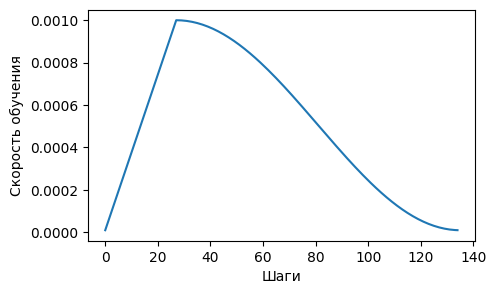

In [15]:
plt.figure(figsize=(5, 3))
plt.plot(range(len(lrs)), lrs)
plt.ylabel("Скорость обучения")
plt.xlabel("Шаги")
plt.show()

- И быстрый взгляд на кривые функции потерь

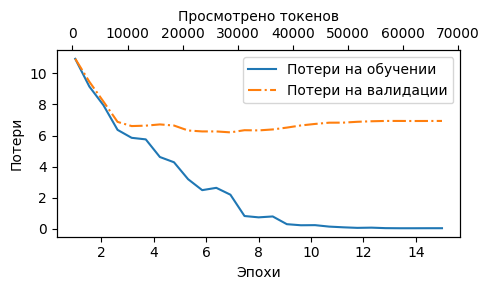

In [16]:
from previous_chapters import plot_losses

epochs_tensor = torch.linspace(1, n_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)
plt.tight_layout(); plt.savefig("3.pdf")
plt.show()

- Модель здесь переобучается, потому что набор данных намеренно сделан очень маленьким в образовательных целях (чтобы код можно было выполнить на ноутбуке)
- Для более длительного предобучения на гораздо большем наборе данных см. [../../ch05/03_bonus_pretraining_on_gutenberg](../../ch05/03_bonus_pretraining_on_gutenberg)